# D2C Customer Churn Intelligence & Retention Project

## Part 1: Data Audit, EDA & Business Understanding

### Objective

The objective of this analysis is to understand customer behavior, audit data quality, identify churn-risk patterns, and generate business insights before building retention strategies and predictive models.

In [192]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

## 1.Load and inspect all raw datasets:

# Load Raw Datasets

All datasets are loaded into pandas dataframes for analysis.

In [193]:
customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
tickets = pd.read_csv("support_tickets.csv")
web = pd.read_csv("web_events_snapshot.csv")
campaigns = pd.read_csv("intervention_history.csv")
churn = pd.read_csv("churn_labels.csv")

# Dataset Inspection

This section inspects dataset dimensions, schema, and sample records.

In [194]:
datasets = {
    "Customers": customers,
    "Orders": orders,
    "Support Tickets": tickets,
    "Web Events": web,
    "Campaigns": campaigns,
    "Churn Labels": churn
}

for name, df in datasets.items():
    print("="*50)
    print(name)
    print("Shape:", df.shape)

Customers
Shape: (2400, 9)
Orders
Shape: (10009, 10)
Support Tickets
Shape: (1921, 8)
Web Events
Shape: (2400, 10)
Campaigns
Shape: (2400, 5)
Churn Labels
Shape: (2400, 4)


# Sample Records

Reviewing the first few rows of each dataset.

In [195]:
customers.head()

,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
0,CUST00001,4/24/2024,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes
1,CUST00002,6/1/2025,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes
2,CUST00003,3/8/2025,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes
3,CUST00004,4/15/2025,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No
4,CUST00005,8/21/2024,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes


In [196]:
orders.head()

,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.0
3,ORD000005,CUST00001,2025-01-22,Hair Care,1,433.15,0.27,2,0,4.0
4,ORD000004,CUST00001,2025-02-28,Skin Care,1,569.22,0.34,4,0,4.0


In [197]:
tickets.head()

,ticket_id,customer_id,ticket_date,issue_type,support_channel,resolution_hours,sentiment_score,reopened
0,TKT000001,CUST00001,10/28/2024,damaged_item,chat,3.9,-0.16,0
1,TKT000002,CUST00001,2/3/2025,payment_issue,chat,4.8,0.44,0
2,TKT000003,CUST00002,8/30/2025,late_delivery,chat,1.0,0.00,0
3,TKT000004,CUST00005,5/2/2025,late_delivery,call,37.7,-1.00,0
4,TKT000005,CUST00006,8/13/2025,general_query,call,23.1,-0.68,1


In [198]:
web.head()

,customer_id,snapshot_date,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
0,CUST00001,2025-09-30,1,4,0,0,0,2,0,20
1,CUST00002,2025-09-30,8,31,4,2,3,0,0,0
2,CUST00003,2025-09-30,1,3,0,0,0,0,0,26
3,CUST00004,2025-09-30,1,6,0,0,0,0,0,14
4,CUST00005,2025-09-30,18,95,4,1,1,3,1,9


In [199]:
campaigns.head()

,customer_id,snapshot_date,last_campaign_received,last_campaign_cost,manual_priority_bucket
0,CUST00001,9/30/2025,welcome_offer,25,high
1,CUST00002,9/30/2025,free_shipping,12,medium
2,CUST00003,9/30/2025,none,18,high
3,CUST00004,9/30/2025,free_shipping,40,high
4,CUST00005,9/30/2025,welcome_offer,18,medium


In [200]:
churn.head()

,customer_id,snapshot_date,churn_next_60d,split
0,CUST00001,2025-09-30,1,train
1,CUST00002,2025-09-30,0,train
2,CUST00003,2025-09-30,1,train
3,CUST00004,2025-09-30,1,train
4,CUST00005,2025-09-30,0,train


# Schema Inspection

Understanding column types and null values.

In [201]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          2400 non-null   object
 1   signup_date          2400 non-null   object
 2   city_tier            2400 non-null   object
 3   age_group            2400 non-null   object
 4   acquisition_channel  2400 non-null   object
 5   loyalty_tier         1014 non-null   object
 6   preferred_category   2400 non-null   object
 7   skin_type            1999 non-null   object
 8   marketing_consent    2400 non-null   object
dtypes: object(9)
memory usage: 168.9+ KB


In [202]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10009 entries, 0 to 10008
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       10009 non-null  object 
 1   customer_id    10009 non-null  object 
 2   order_date     10009 non-null  object 
 3   category       10009 non-null  object 
 4   quantity       10009 non-null  int64  
 5   gross_amount   10009 non-null  float64
 6   discount_pct   10009 non-null  float64
 7   delivery_days  10009 non-null  int64  
 8   returned       10009 non-null  int64  
 9   rating         9929 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 782.1+ KB


In [203]:
tickets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1921 entries, 0 to 1920
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ticket_id         1921 non-null   object 
 1   customer_id       1921 non-null   object 
 2   ticket_date       1921 non-null   object 
 3   issue_type        1921 non-null   object 
 4   support_channel   1921 non-null   object 
 5   resolution_hours  1921 non-null   float64
 6   sentiment_score   1921 non-null   float64
 7   reopened          1921 non-null   int64  
dtypes: float64(2), int64(1), object(5)
memory usage: 120.2+ KB


In [204]:
web.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          2400 non-null   object
 1   snapshot_date        2400 non-null   object
 2   sessions_30d         2400 non-null   int64 
 3   product_views_30d    2400 non-null   int64 
 4   cart_adds_30d        2400 non-null   int64 
 5   wishlist_adds_30d    2400 non-null   int64 
 6   abandoned_carts_30d  2400 non-null   int64 
 7   email_opens_30d      2400 non-null   int64 
 8   campaign_clicks_30d  2400 non-null   int64 
 9   last_visit_days_ago  2400 non-null   int64 
dtypes: int64(8), object(2)
memory usage: 187.6+ KB


In [205]:
campaigns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   customer_id             2400 non-null   object
 1   snapshot_date           2400 non-null   object
 2   last_campaign_received  2400 non-null   object
 3   last_campaign_cost      2400 non-null   int64 
 4   manual_priority_bucket  2400 non-null   object
dtypes: int64(1), object(4)
memory usage: 93.9+ KB


In [206]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     2400 non-null   object
 1   snapshot_date   2400 non-null   object
 2   churn_next_60d  2400 non-null   int64 
 3   split           2400 non-null   object
dtypes: int64(1), object(3)
memory usage: 75.1+ KB


##2. Create a data-quality report covering:

# Data Quality Assessment

The following checks are performed:

1. Missing Values
2. Duplicate Records
3. Invalid Values
4. Outliers
5. Join Validation
6. Date Consistency
7. Leakage Risks

## Missing Value Analysis

This section identifies missing values and evaluates their impact.

In [207]:
for name, df in datasets.items():

    print("\n")
    print("="*50)
    print(name)

    missing = pd.DataFrame({
        "Missing Count": df.isnull().sum(),
        "Missing %": round(
            (df.isnull().sum()/len(df))*100,
            2
        )
    })

    display(
        missing[missing["Missing Count"] > 0]
        .sort_values(
            "Missing %",
            ascending=False
        )
    )



Customers


,Missing Count,Missing %
loyalty_tier,1386,57.75
skin_type,401,16.71




Orders


,Missing Count,Missing %
rating,80,0.8




Support Tickets


...

,Missing Count,Missing %




Campaigns


,Missing Count,Missing %




Churn Labels


,Missing Count,Missing %


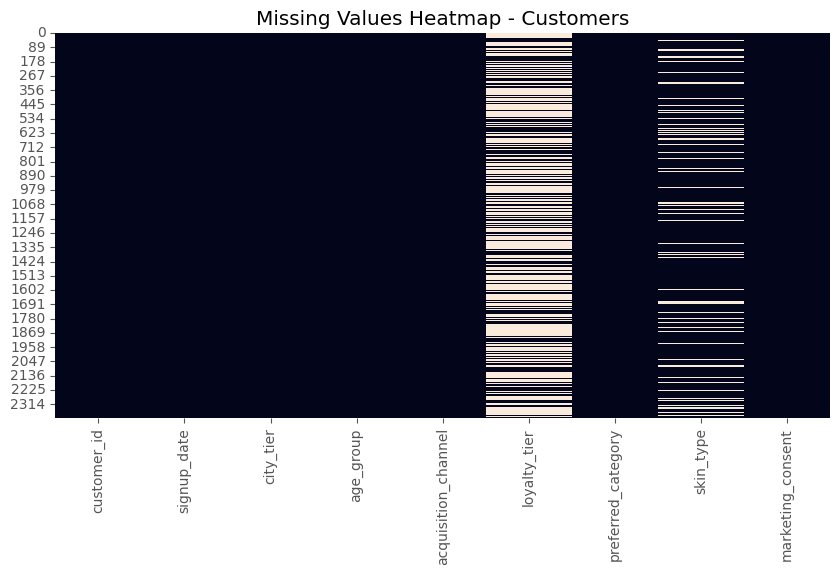

In [208]:
plt.figure(figsize=(10,5))

sns.heatmap(
    customers.isnull(),
    cbar=False
)

plt.title("Missing Values Heatmap - Customers")

plt.show()

### Observation

Missing values are present in the following columns:

- loyalty_tier
- skin_type
- rating

These missing values represent incomplete customer information and may affect segmentation and behavioral analysis.

### Recommendation

- Missing loyalty_tier values can be treated as "Not Enrolled".
- Missing skin_type values can be categorized as "Unknown".
- Missing ratings should not be replaced with zero because no rating does not imply dissatisfaction.

## Duplicate and Duplicate-like Records Analysis

This section identifies exact duplicates and duplicate-like records.

In [209]:
print(
    "Duplicate Rows in Orders:",
    orders.duplicated().sum()
)

Duplicate Rows in Orders: 0


In [210]:
dup_orders = orders[
    orders["order_id"]
    .str.contains("_DUP", na=False)
]

print(
    "Duplicate-like Records:",
    dup_orders.shape[0]
)

dup_orders.head()

Duplicate-like Records: 12


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
601,ORD008249_DUP,CUST00153,2025-11-04,Hair Care,1,321.31,0.36,8,0,3.0
2621,ORD002124_DUP,CUST00628,2025-03-18,Skin Care,1,410.04,0.47,3,0,5.0
3534,ORD002862_DUP,CUST00837,2025-07-12,Hair Care,3,952.02,0.47,4,0,4.0
3602,ORD002916_DUP,CUST00848,2025-09-26,Skin Care,1,547.18,0.28,2,0,5.0
3675,ORD002970_DUP,CUST00869,2024-12-22,Fragrance,1,818.64,0.18,2,0,4.0


### Observation

The orders dataset contains duplicate-like records.

Several order IDs end with "_DUP", indicating intentionally created duplicate-like records for data quality assessment.

### Recommendation

These records should be reviewed before aggregation and feature engineering to avoid double counting of transactions.

## Invalid and Unusual Values Analysis

This section validates whether values fall within expected business ranges.

In [211]:
orders["rating"].value_counts(
    dropna=False
)

,count
rating,
5.0,3750
4.0,3173
3.0,1664
2.0,803
1.0,539
NaN,80


In [212]:
orders["returned"].value_counts()

,count
returned,
0,9334
1,675


In [213]:
customers["marketing_consent"].value_counts()

,count
marketing_consent,
Yes,1760
No,640


### Observation

No major invalid values were identified.

Ratings remain within the expected range and binary variables are consistent.

## Outlier Analysis

This section identifies unusually high order values.

In [214]:
orders["gross_amount"].describe()

,gross_amount
count,10009.000000
mean,743.898504
std,600.564068
min,149.000000
25%,432.850000
50%,597.060000
75%,907.430000
max,24789.380000


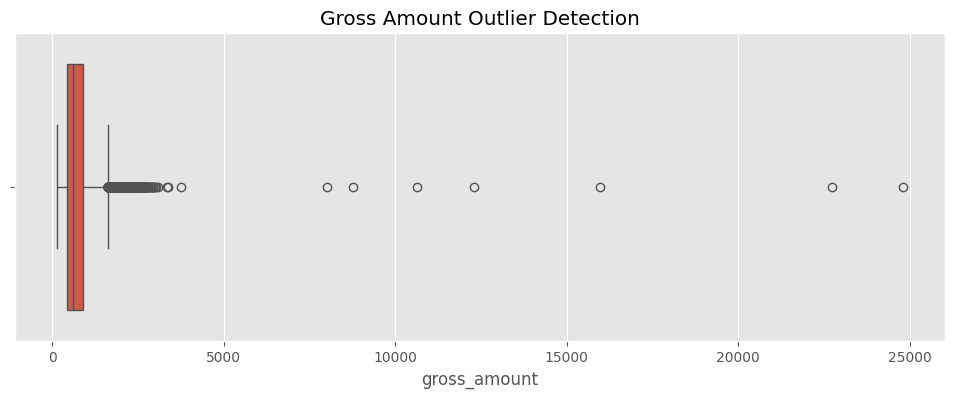

In [215]:
plt.figure(figsize=(12,4))

sns.boxplot(
    x=orders["gross_amount"]
)

plt.title(
    "Gross Amount Outlier Detection"
)

plt.show()

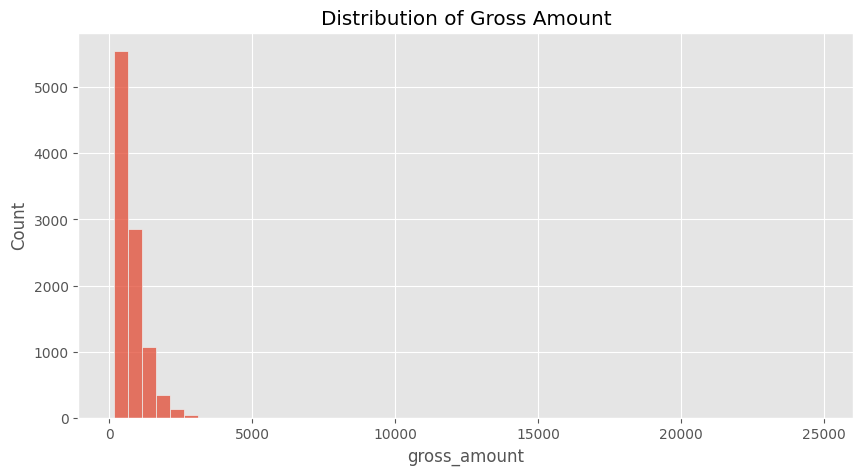

In [216]:
plt.figure(figsize=(10,5))

sns.histplot(
    orders["gross_amount"],
    bins=50
)

plt.title(
    "Distribution of Gross Amount"
)

plt.show()

### Observation

No major invalid values were identified during the analysis.

Ratings remain within the expected range, binary variables contain valid values, and categorical fields appear consistent.

### Recommendation

Continue validating business rules during feature engineering to ensure data consistency.

## Join and Key Validation

Customer_id is validated across all datasets.

In [217]:
print(
    orders["customer_id"]
    .isin(customers["customer_id"])
    .value_counts()
)

customer_id
True    10009
Name: count, dtype: int64


In [218]:
print(
    tickets["customer_id"]
    .isin(customers["customer_id"])
    .value_counts()
)

customer_id
True    1921
Name: count, dtype: int64


In [219]:
print(
    web["customer_id"]
    .isin(customers["customer_id"])
    .value_counts()
)

customer_id
True    2400
Name: count, dtype: int64


In [220]:
print(
    campaigns["customer_id"]
    .isin(customers["customer_id"])
    .value_counts()
)

customer_id
True    2400
Name: count, dtype: int64


In [221]:
print(
    churn["customer_id"]
    .isin(customers["customer_id"])
    .value_counts()
)

customer_id
True    2400
Name: count, dtype: int64


### Observation

Customer IDs are consistently available across all datasets.

The datasets can be successfully connected using customer_id, enabling customer-level analysis.

### Recommendation

Customer-level analysis should use customers.csv as the primary table and perform left joins with supporting datasets.


## Date Consistency Validation

Date fields are converted and validated.

In [222]:
orders["order_date"] = pd.to_datetime(
    orders["order_date"]
)

tickets["ticket_date"] = pd.to_datetime(
    tickets["ticket_date"]
)

In [223]:
print(
    "Order Date Min:",
    orders["order_date"].min()
)

print(
    "Order Date Max:",
    orders["order_date"].max()
)

Order Date Min: 2024-01-09 00:00:00
Order Date Max: 2025-11-29 00:00:00


In [224]:
print(
    "Ticket Date Min:",
    tickets["ticket_date"].min()
)

print(
    "Ticket Date Max:",
    tickets["ticket_date"].max()
)

Ticket Date Min: 2024-01-13 00:00:00
Ticket Date Max: 2025-09-30 00:00:00


### Observation

Date validation shows that some orders occur after the snapshot date (2025-09-30).

These records exist for churn-label creation and represent future information.

### Recommendation

Orders occurring after the snapshot date must not be used during feature creation or predictive modeling.

## Leakage Risk Assessment

Future information must not be used while building churn prediction models.

In [225]:
snapshot_date = pd.Timestamp(
    "2025-09-30"
)

post_snapshot_orders = orders[
    orders["order_date"] >
    snapshot_date
]

print(
    "Post Snapshot Orders:",
    post_snapshot_orders.shape
)

Post Snapshot Orders: (1872, 10)


### Observation

Potential leakage sources were identified in the dataset.

Future order activity and churn labels contain information that would not have been available at prediction time.

### Recommendation

The following should never be used as model inputs:

- churn_next_60d
- Post-snapshot orders
- Features derived from future customer activity

Using these fields would lead to unrealistic model performance.

## Key Findings

1. Missing values exist in loyalty_tier, skin_type, and rating.
2. Duplicate-like order records are present.
3. High-value order outliers were identified.
4. Customer IDs are consistent across datasets.
5. Post-snapshot orders introduce potential leakage risks.

## Recommended Actions

- Handle missing categorical values appropriately.
- Review duplicate-like records before aggregation.
- Investigate extreme order values.
- Exclude post-snapshot records from modeling datasets.
- Prevent leakage by avoiding future information during feature engineering.

## Conclusion

Overall data quality is suitable for exploratory analysis and future predictive modeling. However, missing values, duplicate-like records, outliers, and leakage risks should be carefully managed before model development.


##3. Perform exploratory analysis on:

# Exploratory Data Analysis (EDA)

## Objective

The objective of this exploratory analysis is to understand customer behavior, purchasing patterns, support interactions, digital engagement, and churn-related characteristics.

The analysis covers:

- Customer demographics and profile attributes
- Order behaviour
- Monetary behaviour
- Support-ticket issues
- Return and refund behaviour
- Web and app activity
- Campaign and intervention history
- Churn distribution

The insights generated from this analysis will be used to formulate churn-risk hypotheses and guide future retention strategies.

# Customer Demographic Analysis

## Purpose

This section analyzes customer profile attributes to understand the composition of the customer base and identify important demographic patterns.

## Age Group Distribution

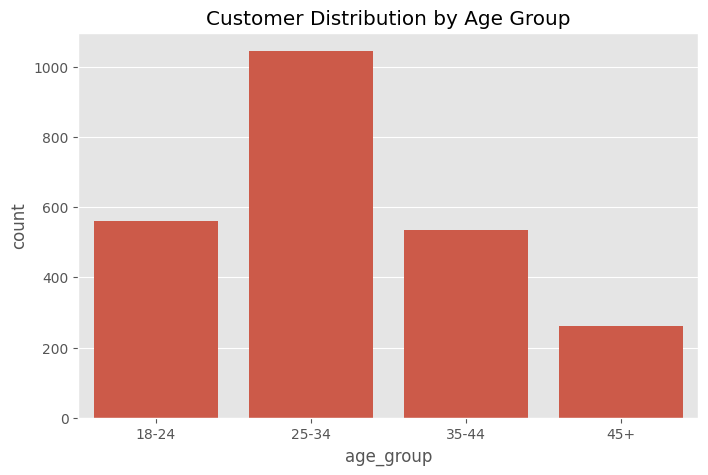

In [226]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=customers,
    x="age_group"
)

plt.title("Customer Distribution by Age Group")

plt.show()

### Observation

Customers are distributed across multiple age groups.

### Business Interpretation

Age-group analysis helps identify which customer segments contribute most to the customer base.

## City Tier Distribution

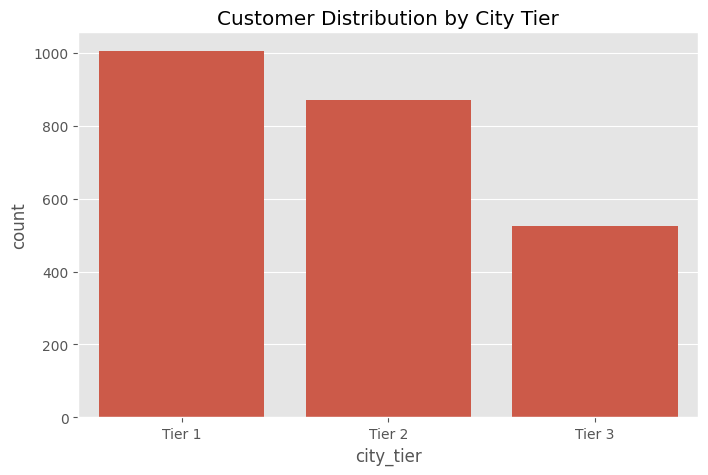

In [227]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=customers,
    x="city_tier"
)

plt.title("Customer Distribution by City Tier")

plt.show()

### Observation

Customers belong to Tier 1, Tier 2, and Tier 3 cities.

### Business Interpretation

Geographic distribution helps understand market penetration and customer reach.

##Acquisition Channel Distribution

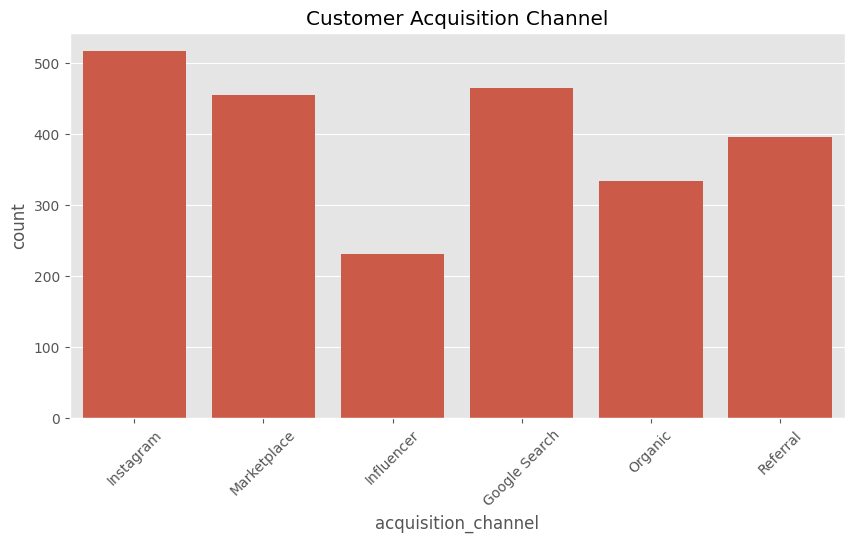

In [228]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=customers,
    x="acquisition_channel"
)

plt.xticks(rotation=45)

plt.title("Customer Acquisition Channel")

plt.show()


### Observation

Customers were acquired through multiple marketing channels.

### Business Interpretation

Some channels may attract higher-quality customers than others.

### Recommendation

Further churn analysis should be performed at the acquisition-channel level to identify channels that bring long-term customers.

##Loyalty Tier Distribution

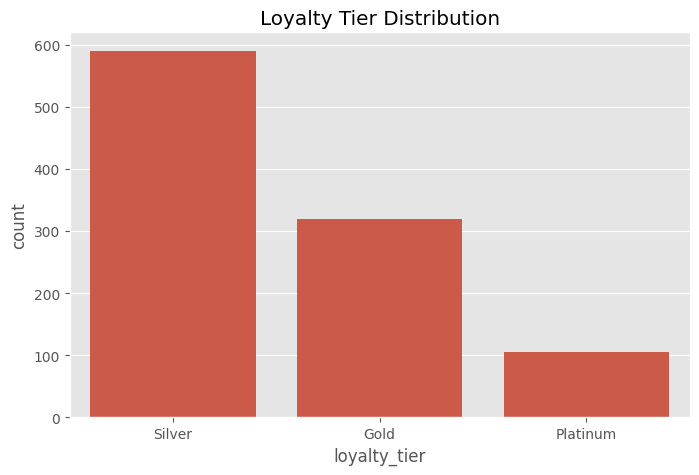

In [229]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=customers,
    x="loyalty_tier"
)

plt.title("Loyalty Tier Distribution")

plt.show()

### Observation

Only a subset of customers are enrolled in loyalty programs.

### Business Interpretation

Loyalty membership may improve customer engagement and retention.

### Recommendation

The company should encourage loyalty-program enrollment through targeted incentives and rewards.


##Preferred Category Distribution

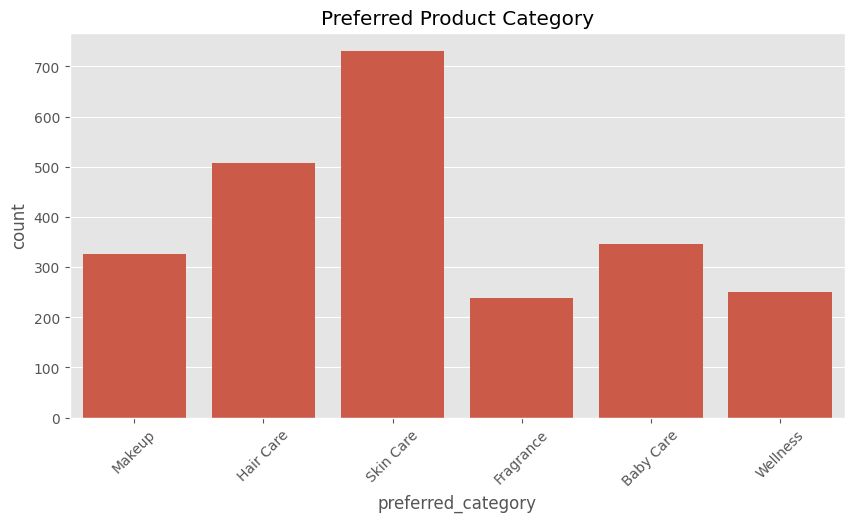

In [230]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=customers,
    x="preferred_category"
)

plt.xticks(rotation=45)

plt.title("Preferred Product Category")

plt.show()

### Observation

Customer preferences vary across product categories.

### Business Interpretation

Category preferences can be used to design personalized marketing campaigns.

# Order Behaviour Analysis

## Purpose

This section analyzes customer purchasing patterns and order behavior.

##Orders by Category

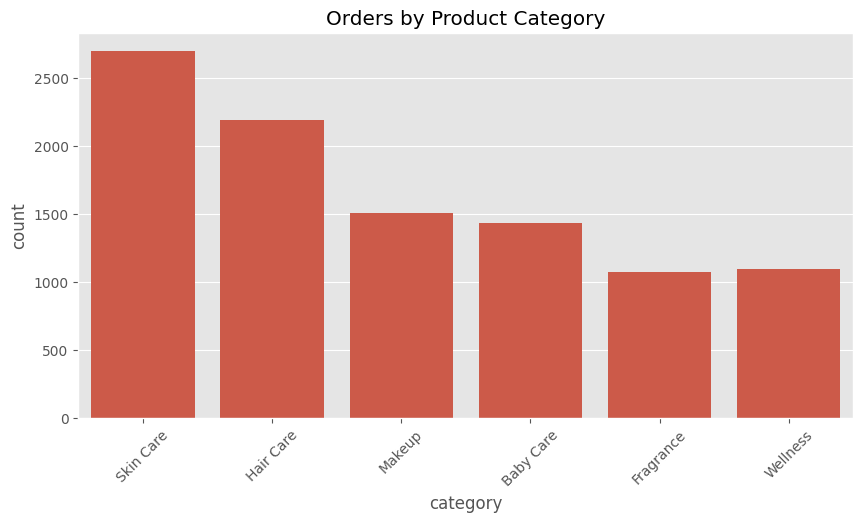

In [231]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=orders,
    x="category"
)

plt.xticks(rotation=45)

plt.title("Orders by Product Category")

plt.show()

### Observation

Orders are distributed across multiple product categories.

### Business Interpretation

Popular categories contribute significantly to overall business performance.

##Rating Distribution

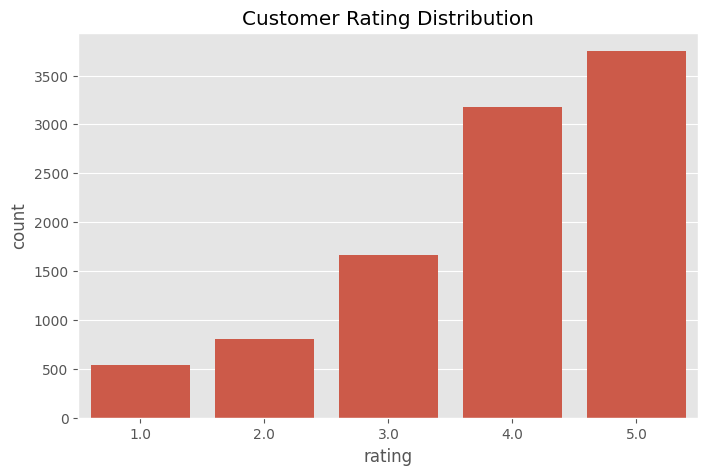

In [232]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=orders,
    x="rating"
)

plt.title("Customer Rating Distribution")

plt.show()

### Observation

Customer ratings vary across transactions.

### Business Interpretation

Lower ratings may indicate dissatisfaction and increased churn risk.

### Recommendation

Customers providing low ratings should be monitored and included in retention campaigns.


## Quantity Analysis

Purpose

This analysis evaluates the number of units purchased per order.

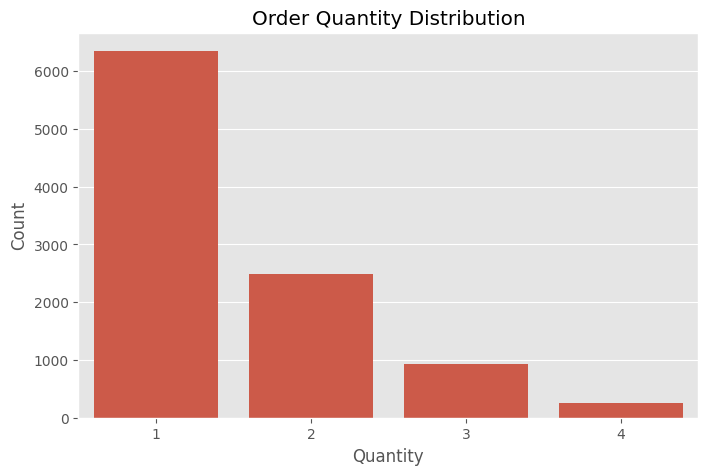

In [233]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=orders,
    x="quantity"
)

plt.title("Order Quantity Distribution")

plt.xlabel("Quantity")
plt.ylabel("Count")

plt.show()

### Observation

Customers purchase varying quantities across orders.

### Business Interpretation

Order quantity helps understand customer purchasing behaviour and buying intent.

### Recommendation

Customers with consistently low purchase quantities should be monitored for engagement and retention opportunities.

## Delivery Days Analysis

Purpose

This analysis evaluates order delivery performance and customer experience.

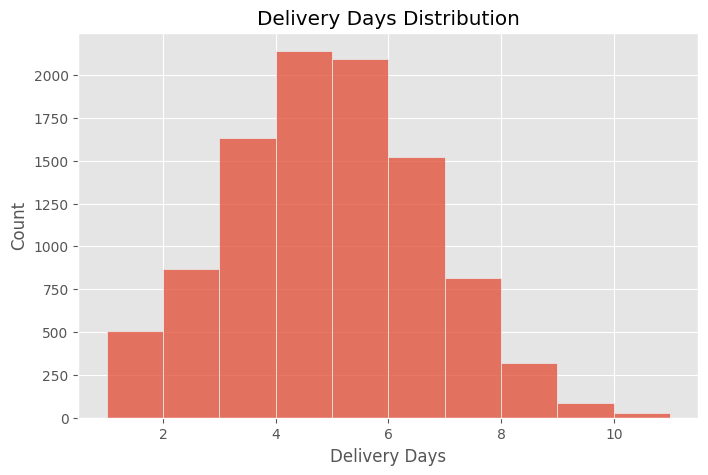

In [234]:
plt.figure(figsize=(8,5))

sns.histplot(
    orders["delivery_days"],
    bins=10
)

plt.title("Delivery Days Distribution")

plt.xlabel("Delivery Days")

plt.show()

### Observation

Delivery times vary across customer orders.

### Business Interpretation

Long delivery times can negatively impact customer satisfaction and loyalty.

### Recommendation

Customers affected by delayed deliveries should be evaluated as potential churn-risk segments.

## Discount Analysis

Purpose

This analysis evaluates discount usage across customer orders.

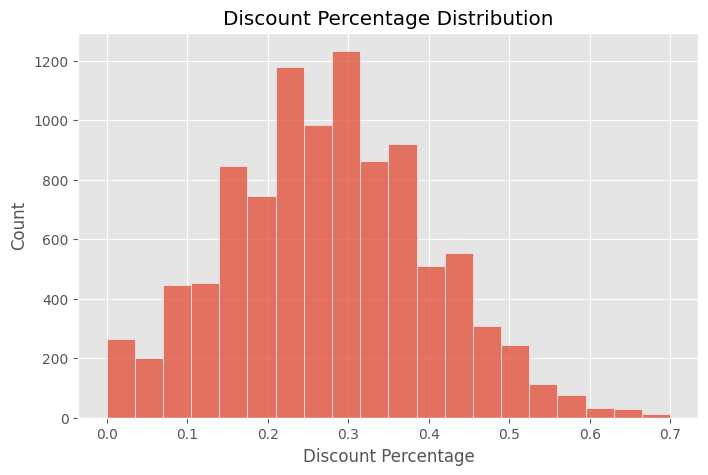

In [235]:
plt.figure(figsize=(8,5))

sns.histplot(
    orders["discount_pct"],
    bins=20
)

plt.title("Discount Percentage Distribution")

plt.xlabel("Discount Percentage")

plt.show()

### Observation

Customers receive different discount levels across transactions.

### Business Interpretation

Some customers may be highly discount-sensitive and depend on promotions to purchase.

### Recommendation

The company should investigate whether discount-heavy customers remain loyal without promotional offers.

## Orders per Customer Analysis

### Purpose

This analysis evaluates purchase frequency across customers.

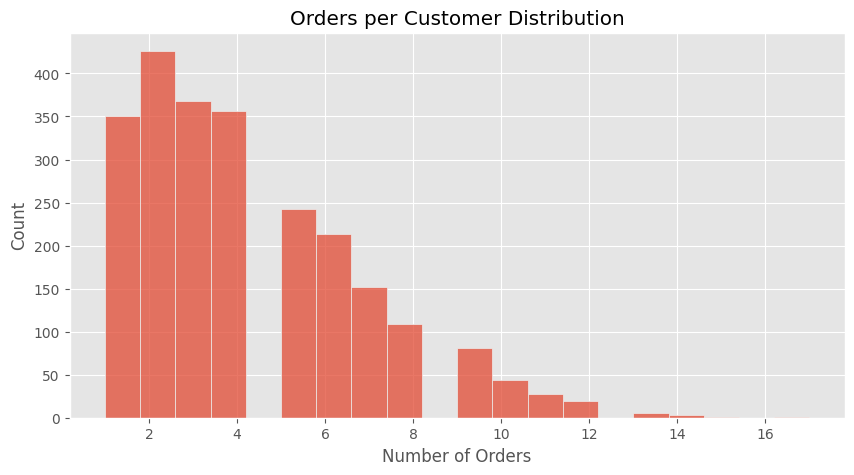

In [236]:
orders_per_customer = (
    orders.groupby("customer_id")
    .size()
    .reset_index(name="order_count")
)

plt.figure(figsize=(10,5))

sns.histplot(
    orders_per_customer["order_count"],
    bins=20
)

plt.title("Orders per Customer Distribution")

plt.xlabel("Number of Orders")

plt.show()

### Observation

Customer purchase frequency varies significantly across the customer base.

### Business Interpretation

Customers with fewer purchases may have weaker engagement and higher churn risk.

### Recommendation

Purchase frequency should be incorporated into future churn-risk analysis and retention planning.

# Monetary Behaviour Analysis

Purpose

This section evaluates customer spending patterns and transaction values.

## Gross Amount Distribution

Purpose

This analysis evaluates the distribution of order values across customers.

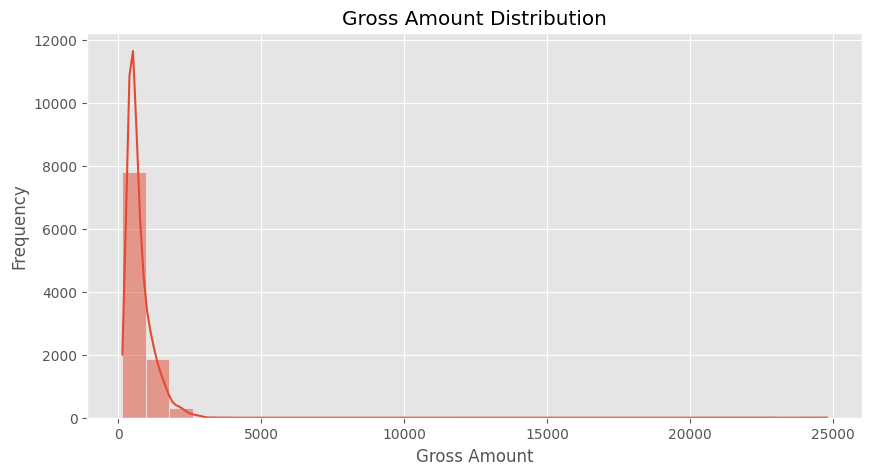

In [237]:
plt.figure(figsize=(10,5))

sns.histplot(
    orders["gross_amount"],
    bins=30,
    kde=True
)

plt.title("Gross Amount Distribution")
plt.xlabel("Gross Amount")
plt.ylabel("Frequency")

plt.show()

### Observation

Order values vary across customers, with some transactions significantly larger than others.

### Business Interpretation

Understanding spending distribution helps identify typical purchase behavior and potential high-value customers.

### Recommendation

Extreme high-value transactions should be investigated separately to determine whether they represent VIP customers or outliers.

## Average Spending Analysis

Purpose

This analysis evaluates average customer spending and spending variation.

In [238]:
orders["gross_amount"].describe()

,gross_amount
count,10009.000000
mean,743.898504
std,600.564068
min,149.000000
25%,432.850000
50%,597.060000
75%,907.430000
max,24789.380000


### Observation

Summary statistics provide insights into average order value and spending variation.

### Business Interpretation

Customers with higher average spending contribute more revenue and should be monitored closely.

### Recommendation

Average spending metrics should be incorporated into future customer segmentation and retention planning.

## High Value Customer Analysis

Purpose

This analysis identifies customers contributing the highest revenue.

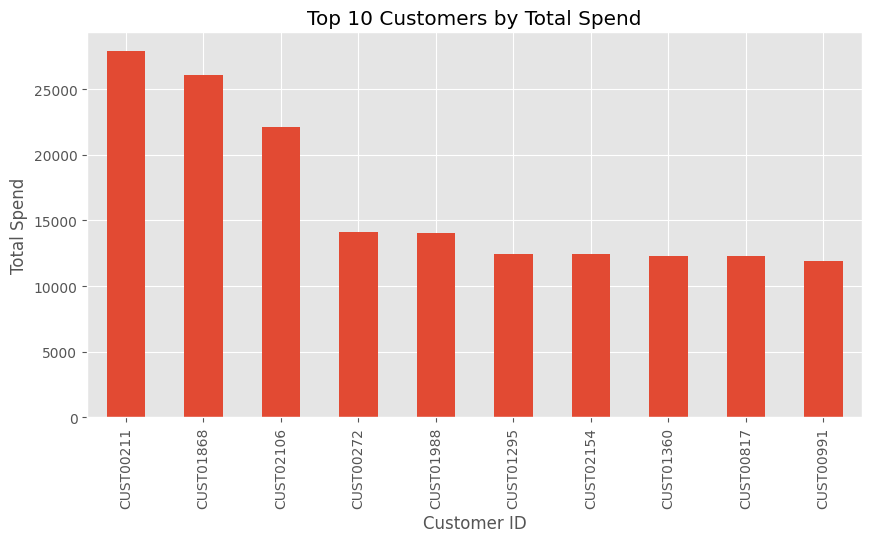

In [239]:
top_customers = (
    orders.groupby("customer_id")["gross_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

top_customers.plot(kind="bar")

plt.title("Top 10 Customers by Total Spend")
plt.xlabel("Customer ID")
plt.ylabel("Total Spend")

plt.show()

### Observation

A small number of customers contribute a significant share of total revenue.

### Business Interpretation

Revenue concentration indicates that losing high-value customers could have a substantial business impact.

### Recommendation

High-value customers should be prioritized in retention and loyalty initiatives.

## Revenue by Product Category

Purpose

This analysis evaluates revenue contribution across different product categories.

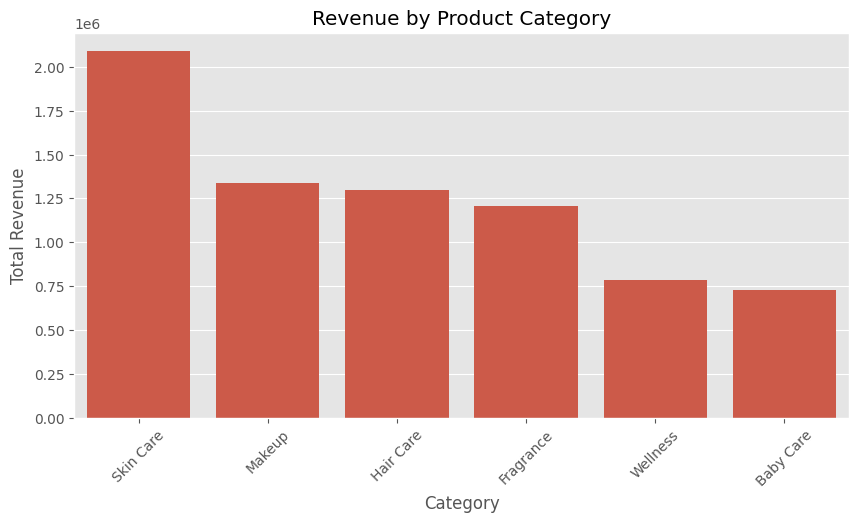

In [240]:
category_spend = (
    orders.groupby("category")["gross_amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=category_spend.index,
    y=category_spend.values
)

plt.xticks(rotation=45)

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")

plt.show()

### Observation

Revenue contribution varies across product categories.

### Business Interpretation

Some categories generate significantly higher revenue than others and may play a critical role in customer retention.

### Recommendation

High-revenue categories should receive special attention in marketing and retention campaigns.

# Support Ticket Analysis

## Purpose

This section evaluates customer complaints, support interactions, and service quality indicators.

## Issue Type Distribution

Purpose

This analysis identifies the most common customer issues and complaints.

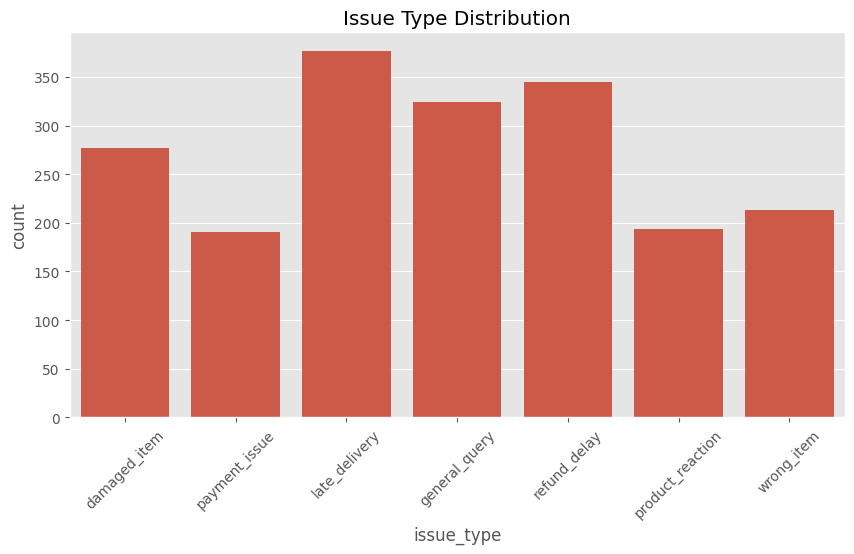

In [241]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=tickets,
    x="issue_type"
)

plt.xticks(rotation=45)

plt.title("Issue Type Distribution")

plt.show()

### Observation

Customers raise different types of support issues.

### Business Interpretation

Frequently occurring issue categories may indicate operational or product-related challenges.

### Recommendation

The company should prioritize reducing the most common customer complaints to improve customer experience.

## Support Channel Distribution

 Purpose

This analysis evaluates customer preferences for support channels.

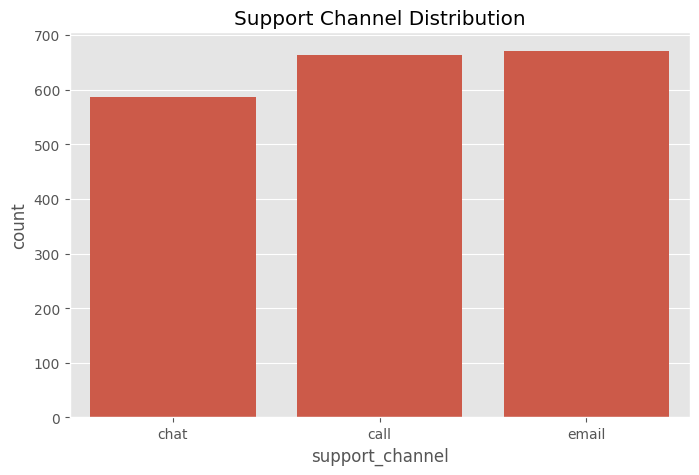

In [242]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=tickets,
    x="support_channel"
)

plt.title("Support Channel Distribution")

plt.show()

### Observation

Customers use multiple support channels to resolve issues.

### Business Interpretation

Channel usage patterns help identify customer communication preferences.

### Recommendation

Support resources should be optimized based on the most frequently used channels.

## Resolution Hours Analysis

Purpose

This analysis evaluates the efficiency of customer support operations.

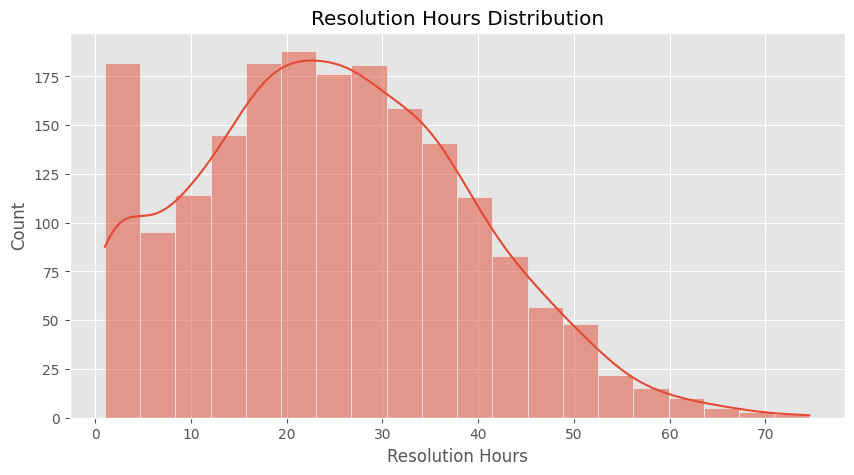

In [243]:
plt.figure(figsize=(10,5))

sns.histplot(
    tickets["resolution_hours"],
    bins=20,
    kde=True
)

plt.title("Resolution Hours Distribution")

plt.xlabel("Resolution Hours")

plt.show()

### Observation

Ticket resolution times vary across customer issues.

### Business Interpretation

Long resolution times may negatively affect customer satisfaction.

### Recommendation

Reducing ticket resolution time may help improve customer retention and service quality.

## Reopened Ticket Analysis

Purpose

This analysis evaluates whether support issues are being resolved effectively.

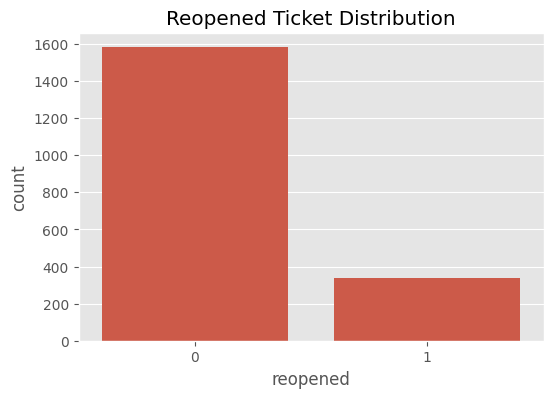

In [244]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=tickets,
    x="reopened"
)

plt.title("Reopened Ticket Distribution")

plt.show()

### Observation

Some tickets are reopened after their initial resolution.

### Business Interpretation

Reopened tickets may indicate unresolved customer concerns and dissatisfaction.

### Recommendation

Customers with reopened tickets should receive additional follow-up and support attention.

## Sentiment Score Analysis

Purpose

This analysis evaluates customer sentiment based on support-ticket interactions.

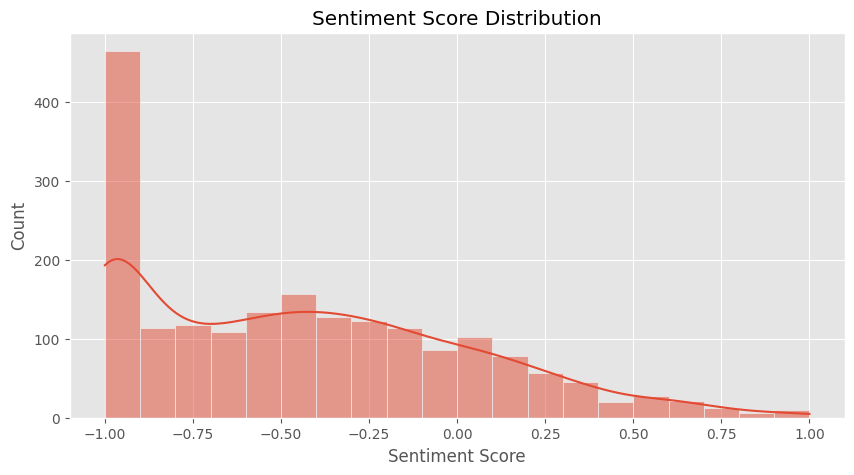

In [245]:
plt.figure(figsize=(10,5))

sns.histplot(
    tickets["sentiment_score"],
    bins=20,
    kde=True
)

plt.title("Sentiment Score Distribution")

plt.xlabel("Sentiment Score")

plt.show()

### Observation

Customer sentiment ranges from highly negative to highly positive.

### Business Interpretation

Negative sentiment may indicate dissatisfaction and increased churn risk.

### Recommendation

Customers with consistently negative sentiment should be prioritized for retention and service recovery initiatives.

# Return and Refund Behaviour Analysis

Purpose

This section investigates return behaviour and refund-related customer dissatisfaction patterns.

## Returned vs Non-Returned Orders

Purpose

This analysis evaluates the proportion of returned and non-returned orders.

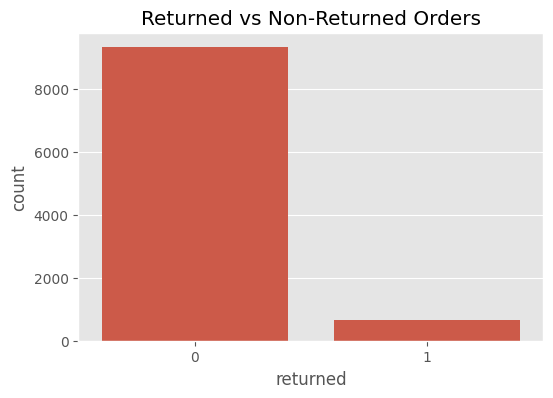

In [246]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=orders,
    x="returned"
)

plt.title("Returned vs Non-Returned Orders")

plt.show()

### Observation

Both returned and non-returned orders are present in the dataset.

### Business Interpretation

Returns may indicate dissatisfaction with products, delivery experience, or customer expectations.

### Recommendation

Customers with frequent returns should be monitored as potential churn-risk segments.

## Return Rate Analysis

Purpose

This analysis evaluates the percentage of returned orders within the overall order population.

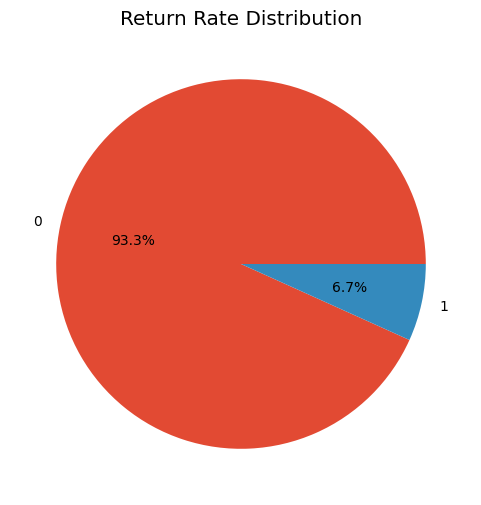

In [247]:
return_rate = (
    orders["returned"]
    .value_counts(normalize=True)
    * 100
)

plt.figure(figsize=(6,6))

plt.pie(
    return_rate,
    labels=return_rate.index,
    autopct="%1.1f%%"
)

plt.title("Return Rate Distribution")

plt.show()

### Observation

A portion of customer orders result in returns.

### Business Interpretation

High return rates may indicate product-quality issues, fulfillment problems, or unmet customer expectations.

### Recommendation

The company should investigate the root causes of returns and implement corrective actions to improve customer satisfaction.

# Web and App Activity Analysis

Purpose

This section analyzes customer engagement across digital channels and online interactions.

## Sessions Analysis

### Purpose

This analysis evaluates customer website and app visit frequency.

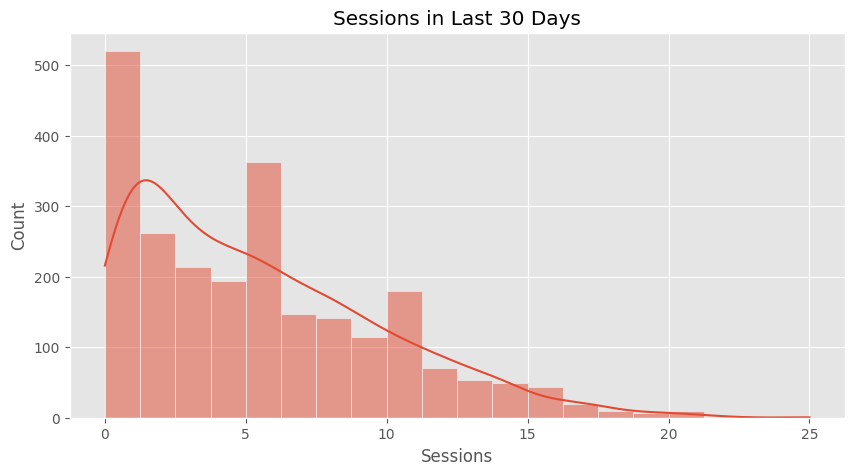

In [248]:
plt.figure(figsize=(10,5))

sns.histplot(
    web["sessions_30d"],
    bins=20,
    kde=True
)

plt.title("Sessions in Last 30 Days")

plt.xlabel("Sessions")

plt.show()

### Observation

Customer session activity varies significantly across users.

### Business Interpretation

Higher session activity generally indicates stronger customer engagement.

### Recommendation

Customers with very low session counts should be monitored for potential churn risk.

## Product Views Analysis

Purpose

This analysis evaluates customer browsing behavior through product views.

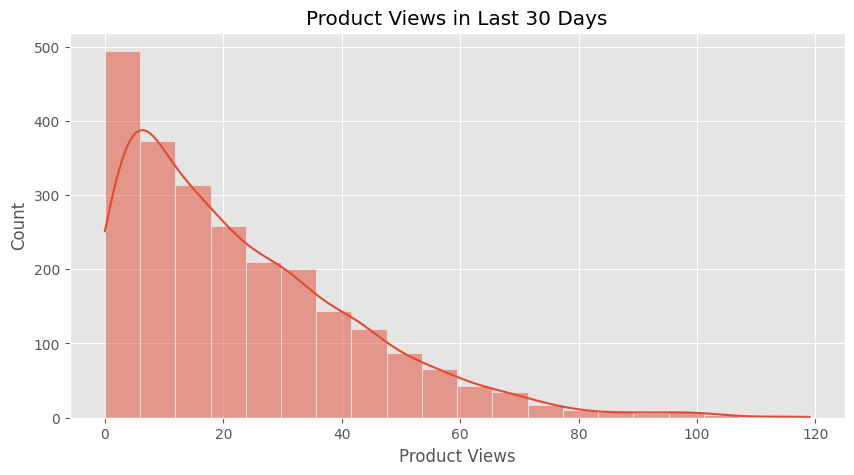

In [249]:
plt.figure(figsize=(10,5))

sns.histplot(
    web["product_views_30d"],
    bins=20,
    kde=True
)

plt.title("Product Views in Last 30 Days")

plt.xlabel("Product Views")

plt.show()

### Observation

Customers exhibit varying levels of product exploration.

### Business Interpretation

Frequent product views indicate interest and engagement with the platform.

### Recommendation

Customers with declining product-view activity may require re-engagement campaigns.

## Cart Adds Analysis

Purpose

This analysis evaluates customer purchase intent through cart activity.

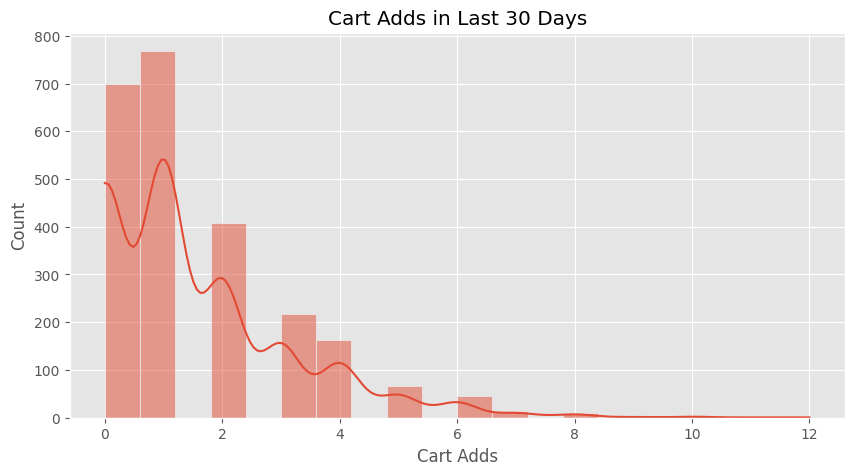

In [250]:
plt.figure(figsize=(10,5))

sns.histplot(
    web["cart_adds_30d"],
    bins=20,
    kde=True
)

plt.title("Cart Adds in Last 30 Days")

plt.xlabel("Cart Adds")

plt.show()

### Observation

Cart activity varies across customers.

### Business Interpretation

Adding products to cart indicates strong purchase consideration.

### Recommendation

Customers with high cart activity but low purchase frequency may benefit from targeted offers.

## Wishlist Adds Analysis

Purpose

This analysis evaluates future purchase interest through wishlist behavior.

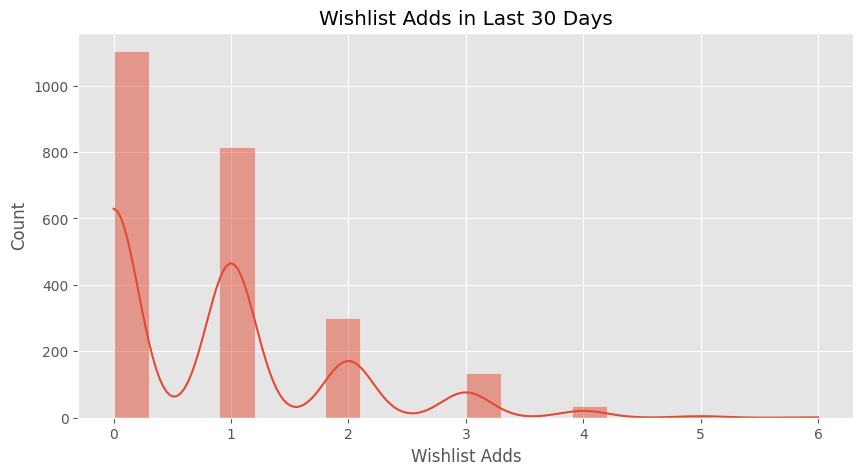

In [251]:
plt.figure(figsize=(10,5))

sns.histplot(
    web["wishlist_adds_30d"],
    bins=20,
    kde=True
)

plt.title("Wishlist Adds in Last 30 Days")

plt.xlabel("Wishlist Adds")

plt.show()

### Observation

Customers add varying numbers of products to their wishlists.

### Business Interpretation

Wishlist activity reflects future purchase consideration and engagement.

### Recommendation

Wishlist-based remarketing campaigns may improve conversion and retention.

## Campaign Click Analysis

Purpose

This analysis evaluates customer interaction with marketing campaigns.

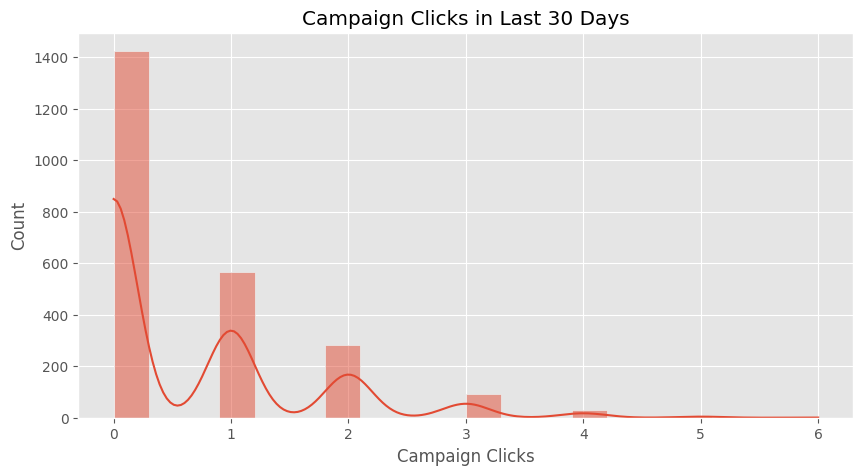

In [252]:
plt.figure(figsize=(10,5))

sns.histplot(
    web["campaign_clicks_30d"],
    bins=20,
    kde=True
)

plt.title("Campaign Clicks in Last 30 Days")

plt.xlabel("Campaign Clicks")

plt.show()

### Observation

Customer engagement with marketing campaigns varies across the customer base.

### Business Interpretation

Campaign clicks provide insight into marketing effectiveness and customer responsiveness.

### Recommendation

Customers with low campaign engagement may require alternative communication strategies.

# Campaign and Intervention Analysis

Purpose

This section evaluates customer exposure to retention campaigns and intervention programs.

## Campaign Distribution Analysis

Purpose

This analysis evaluates customer participation in marketing campaigns.

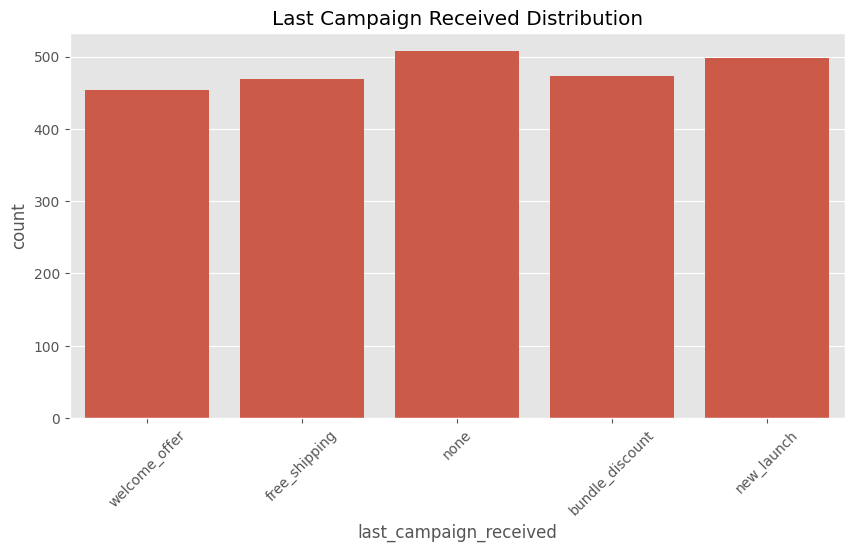

In [253]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=campaigns,
    x="last_campaign_received"
)

plt.xticks(rotation=45)

plt.title("Last Campaign Received Distribution")

plt.show()

### Observation

Customers have received different campaign types.

### Business Interpretation

Campaign exposure may influence customer engagement and retention.

### Recommendation

Campaign effectiveness should be investigated to identify which campaigns generate stronger customer engagement.

## Manual Priority Bucket Analysis

Purpose

This analysis evaluates customer segmentation based on retention priority levels.

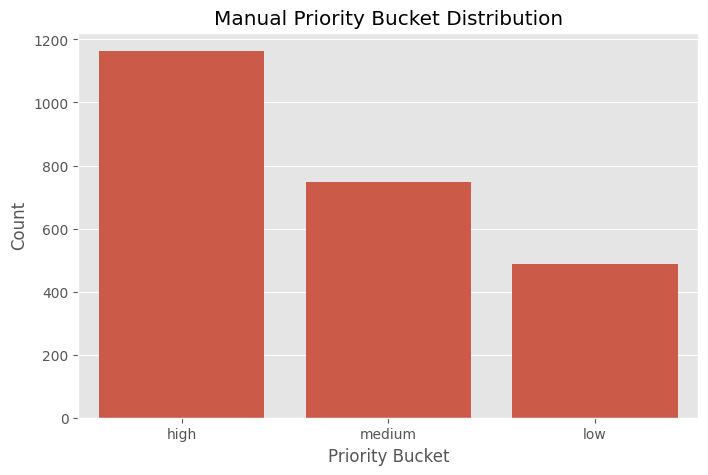

In [254]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=campaigns,
    x="manual_priority_bucket"
)

plt.title("Manual Priority Bucket Distribution")

plt.xlabel("Priority Bucket")
plt.ylabel("Count")

plt.show()

### Observation

Customers are distributed across different priority buckets.

### Business Interpretation

Priority buckets help identify customers requiring different levels of retention attention.

### Recommendation

High-priority customers should be monitored closely and targeted with proactive retention campaigns.

# Churn Distribution Analysis

Purpose

This section examines the distribution of churned and non-churned customers in the dataset. Understanding churn prevalence is important for evaluating customer retention challenges and preparing future predictive modeling efforts.

## Churn Distribution

Purpose

This analysis evaluates the proportion of customers who churned versus those who remained active during the observation period.

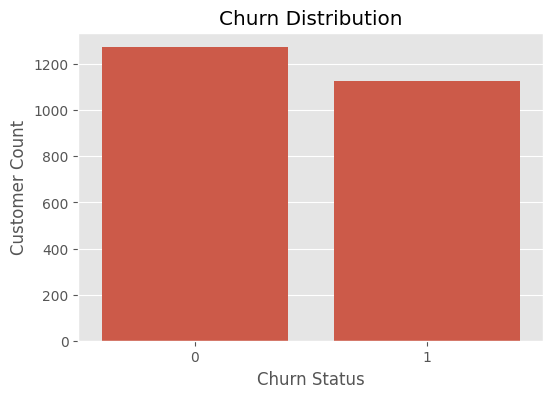

In [255]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=churn,
    x="churn_next_60d"
)

plt.title("Churn Distribution")

plt.xlabel("Churn Status")
plt.ylabel("Customer Count")

plt.show()

### Observation

The dataset contains both churned and non-churned customers. The distribution provides an initial understanding of the scale of customer attrition within the business.

### Business Interpretation

Churn distribution is a critical business metric because it reflects the proportion of customers that the company is losing. Understanding this balance helps assess the severity of the retention problem and provides context for future churn prediction and intervention strategies.

### Recommendation

The company should closely monitor churn levels and investigate the characteristics of customers who leave. If the churned customer population is significantly smaller than the non-churned population, class imbalance techniques should be considered during predictive model development.

4. Five Churn-risk Hypotheses below

# Churn-Risk Hypotheses

Purpose

This section develops data-driven hypotheses regarding factors that may contribute to customer churn. Each hypothesis is supported by exploratory analysis and business interpretation.

## Hypothesis 1: Customers with Lower Web Activity Are More Likely to Churn

### Business Question

Does lower digital engagement increase the likelihood of customer churn?

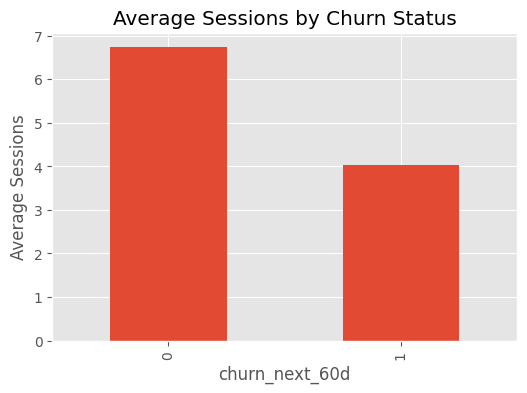

In [256]:
web_churn = web.merge(
    churn,
    on="customer_id"
)

web_churn.groupby(
    "churn_next_60d"
)["sessions_30d"].mean().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Average Sessions by Churn Status")

plt.ylabel("Average Sessions")

plt.show()

### Observation

Non-churned customers (churn_next_60d = 0) show an average of approximately 6.8 sessions, whereas churned customers (churn_next_60d = 1) show an average of approximately 4.1 sessions during the last 30 days.

### Hypothesis

Customers with lower web activity are more likely to churn. Reduced platform engagement appears to be associated with a higher probability of customer attrition.

### Business Impact

Digital engagement can serve as an early warning indicator of churn risk. Customers showing declining session activity should be targeted with personalized engagement campaigns, recommendations, and retention initiatives.

## Hypothesis 2: Customers with More Support Issues Are More Likely to Churn

### Business Question

Do customers experiencing more support-related issues exhibit higher churn risk?

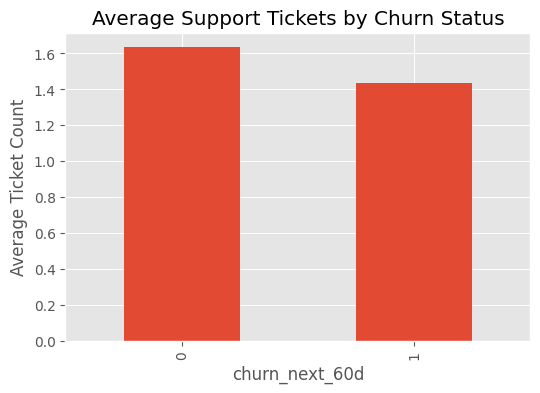

In [257]:
ticket_count = (
    tickets.groupby("customer_id")
    .size()
    .reset_index(name="ticket_count")
)

ticket_churn = ticket_count.merge(
    churn,
    on="customer_id"
)

ticket_churn.groupby(
    "churn_next_60d"
)["ticket_count"].mean().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Average Support Tickets by Churn Status")

plt.ylabel("Average Ticket Count")

plt.show()

### Observation

Non-churned customers show an average of approximately 1.68 support tickets, whereas churned customers show an average of approximately 1.43 support tickets.

### Hypothesis Evaluation

The current analysis does not provide strong evidence that customers with more support tickets are more likely to churn. In this dataset, churned customers appear to raise slightly fewer support tickets than non-churned customers.

### Business Interpretation

This pattern may indicate that engaged customers are more willing to contact support when issues arise, while some dissatisfied customers may disengage and leave without seeking assistance.

### Business Impact

The company should further investigate ticket quality, issue severity, resolution time, and customer sentiment rather than relying solely on ticket volume as an indicator of churn risk.

## Hypothesis 3: High Return Rates Are Associated with Higher Churn

### Business Question

Does product return behaviour indicate dissatisfaction and future churn?

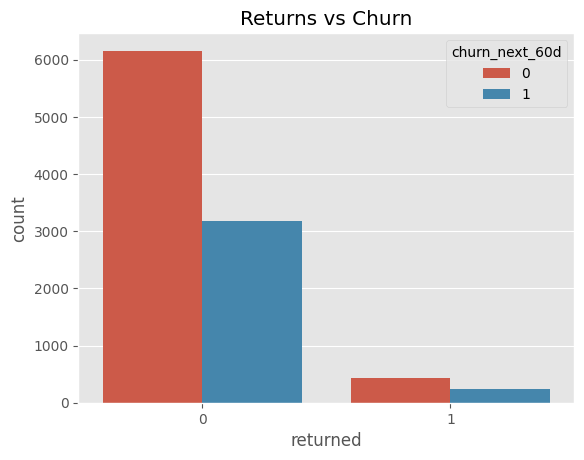

In [258]:
return_churn = orders.merge(
    churn,
    on="customer_id"
)

sns.countplot(
    data=return_churn,
    x="returned",
    hue="churn_next_60d"
)

plt.title("Returns vs Churn")

plt.show()

### Observation

Customers who returned products are present in both churned and non-churned groups. However, returned orders appear more frequently among churned customers relative to their overall population.

### Hypothesis

Customers who return products may have a higher likelihood of churn. Product returns can indicate dissatisfaction with product quality, customer expectations, or overall purchase experience.

### Business Interpretation

Return behaviour may serve as an early warning indicator of customer dissatisfaction and future churn risk.

### Business Impact

Customers with recent return activity should be monitored closely and may benefit from proactive retention initiatives, personalized support, or targeted follow-up campaigns.

## Hypothesis 4: Customers Without Loyalty Membership Have Higher Churn Risk

### Business Question

Does loyalty program participation reduce churn risk?

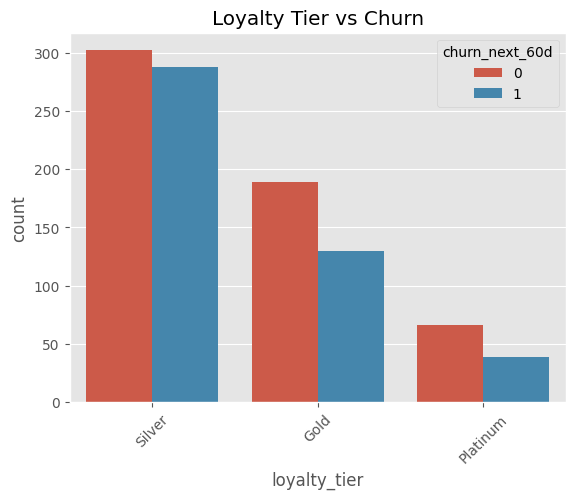

In [259]:
cust_churn = customers.merge(
    churn,
    on="customer_id"
)

sns.countplot(
    data=cust_churn,
    x="loyalty_tier",
    hue="churn_next_60d"
)

plt.title("Loyalty Tier vs Churn")

plt.xticks(rotation=45)

plt.show()

### Observation

Customers are distributed across Silver, Gold, and Platinum loyalty tiers. The Silver tier contains the highest number of both churned and non-churned customers, while Gold and Platinum tiers show comparatively lower churn counts.

### Hypothesis

Customers with lower loyalty-tier participation may exhibit a higher risk of churn compared to customers in higher loyalty tiers.

### Business Interpretation

The chart suggests that loyalty-program engagement may influence customer retention. Customers in higher loyalty tiers appear to have relatively lower churn levels, indicating that loyalty benefits may encourage continued engagement.

### Business Impact

Strengthening loyalty-program participation and encouraging customers to move into higher loyalty tiers may help improve retention and reduce future churn risk.

## Hypothesis 5: Low Campaign Engagement Leads to Higher Churn

### Business Question

Does customer interaction with marketing campaigns influence churn behaviour?

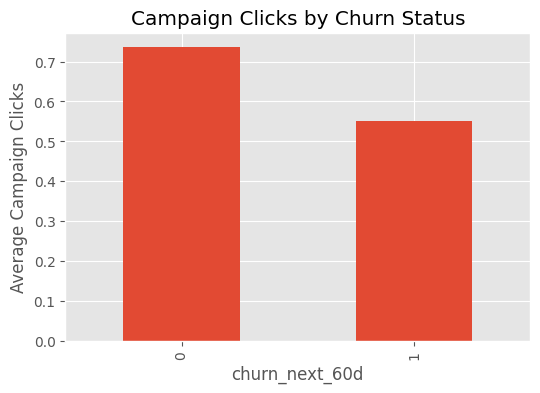

In [260]:
campaign_churn = web.merge(
    churn,
    on="customer_id"
)

campaign_churn.groupby(
    "churn_next_60d"
)["campaign_clicks_30d"].mean().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Campaign Clicks by Churn Status")

plt.ylabel("Average Campaign Clicks")

plt.show()

### Observation

Non-churned customers show an average of approximately 0.73 campaign clicks, whereas churned customers show an average of approximately 0.55 campaign clicks during the observation period.

### Hypothesis

Customers with lower campaign engagement are more likely to churn. Reduced interaction with marketing campaigns appears to be associated with a higher probability of customer attrition.

### Business Interpretation

Campaign engagement reflects customer interest and interaction with the brand. Customers who engage less frequently with campaigns may become less connected to the business and more likely to discontinue purchasing.

### Business Impact

Campaign engagement can be used as an early retention indicator. Customers showing low campaign interaction should be targeted through personalized marketing, promotions, and re-engagement initiatives.

# Key Findings


1. Customer engagement appears to be strongly associated with churn behaviour. Churned customers showed lower average web-session activity compared to non-churned customers.

2. Campaign engagement also appears to be an important retention indicator. Customers who interacted less with marketing campaigns exhibited higher churn levels.

3. Product return behaviour may serve as an early warning signal of customer dissatisfaction and potential churn risk.

4. Loyalty-program participation appears to support customer retention. Higher loyalty tiers generally showed lower churn levels compared to lower tiers.

5. Support-ticket volume alone was not a strong predictor of churn in this dataset. Churned customers did not generate more support tickets than non-churned customers.

6. Revenue is concentrated among a smaller segment of high-value customers, highlighting the importance of retaining premium customers.

7. Customer behaviour, engagement metrics, and loyalty participation appear to be more informative churn indicators than support-ticket volume alone.

# Conclusion


This analysis explored customer demographics, purchasing behaviour, spending patterns, support interactions, web activity, campaign engagement, and churn outcomes to identify potential drivers of customer attrition.

The findings indicate that customer engagement metrics, including web activity and campaign interaction, are strongly associated with churn behaviour. Customers with lower engagement levels were more likely to churn. Product return behaviour and weaker loyalty-program participation also emerged as potential churn-risk indicators. In contrast, support-ticket volume alone did not appear to be a strong predictor of churn in this dataset.

Based on these findings, the company should prioritize initiatives that improve customer engagement, strengthen loyalty-program participation, proactively address customer dissatisfaction, and monitor high-risk behavioural signals. These insights provide a strong foundation for developing retention strategies and building predictive churn models in subsequent phases of the project.